In [64]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [65]:
label_map = {
    "airplane": 0,
    "automobile": 1,
    "bird": 2,
    "cat": 3,
    "deer": 4,
    "dog": 5,
    "frog": 6,
    "horse": 7,
    "ship": 8,
    "truck": 9
}

In [66]:
train_labels = pd.read_csv("./cifar-10/trainLabels.csv").to_numpy()[:, 1]

In [67]:
folder = Path('./cifar-10/train')

def pull_data(folder):
    id_arr = []
    image_arr = []
    label_arr = []

    for file_path in folder.iterdir():
        # Make sure it's a file, not a subfolder
        if file_path.is_file():
            image = np.asarray(Image.open(file_path))
            file_name = file_path.name
            id = int(file_name[:file_name.index(".")])
            id_arr.append(id)
            image_arr.append(image)

    for id in id_arr:
        label = label_map[train_labels[id - 1]]
        label_arr.append(label)

    return id_arr, image_arr, label_arr

In [68]:
id_arr, image_arr, label_arr = pull_data(folder)

In [69]:
data = torch.Tensor(np.asarray(image_arr)).permute(0, 3, 1, 2)
labels = torch.Tensor(np.asarray(label_arr))
labels = labels.unsqueeze(dim=1)

data.shape, labels.shape

(torch.Size([50000, 3, 32, 32]), torch.Size([50000, 1]))

In [70]:
td = TensorDataset(data, labels)
td

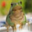

In [71]:
loader = DataLoader(td, batch_size=32)

batch_1 = next(iter(loader))

Image.fromarray(batch_1[0][0].permute(1, 2, 0).numpy().astype(np.uint8))

In [72]:
feature_extractor = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=2, kernel_size=3, stride=1, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2)
)

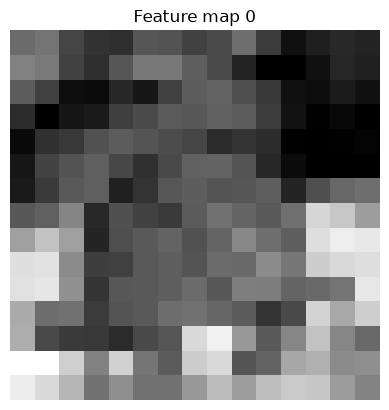

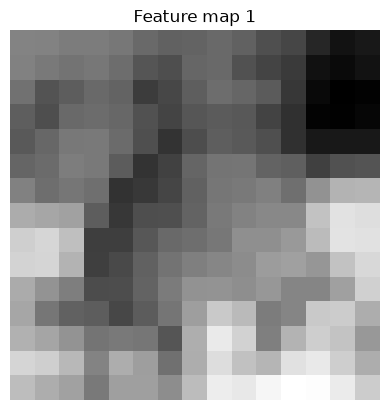

In [ ]:
features = feature_extractor(batch_1[0][0].unsqueeze(0))

print(features)
feature_maps = features[0].detach().cpu()

for i, feature_map in enumerate(feature_maps):
    plt.figure()
    plt.imshow(feature_map.numpy(), cmap="gray")
    plt.title(f"Feature map {i}")
    plt.axis("off")
    plt.show()